In [ ]:
from aereo.backends import LocalProcessBackend
from aereo.client import AereoClient
from aereo.pipeline import ExtractionJob


client = AereoClient()
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_tessera.yaml",
)

In [9]:
# Search
search_results = client.search(job.search)
print(f"✓ Found {len(search_results)} scenes")

2026-06-18 17:40:37 [info     ] search_called                  provider=SearchTessera
✓ Found 2 scenes


In [11]:
# Prepare
print("\n📦 Preparing tasks...")
tasks = client.prepare_tasks(
    search_results=search_results,
    job=job,
    cells_per_task=2,
)
print(f"✓ Prepared {len(tasks)} tasks")


📦 Preparing tasks...
✓ Prepared 2 tasks


In [12]:
# Extract
print("\n⛏️ Extracting...")
backend = LocalProcessBackend(max_workers=2)
artifacts = client.execute_tasks(tasks, backend=backend)
print(f"✓ Extracted {len(artifacts)} artifacts")


⛏️ Extracting...
2026-06-18 17:40:41 [info     ] execute_tasks_start            backend=LocalProcessBackend failure_mode=strict task_count=2
2026-06-18 17:40:57 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/grid_-1.35_51.75.npy
2026-06-18 17:40:57 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/grid_-1.25_51.75.npy
2026-06-18 17:40:57 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/grid_-1.35_51.75.npy
2026-06-18 17:40:57 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/grid_-1.25_51.75.npy
✓ Extracted 4 artifacts


(<Figure size 2000x1979.02 with 1 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


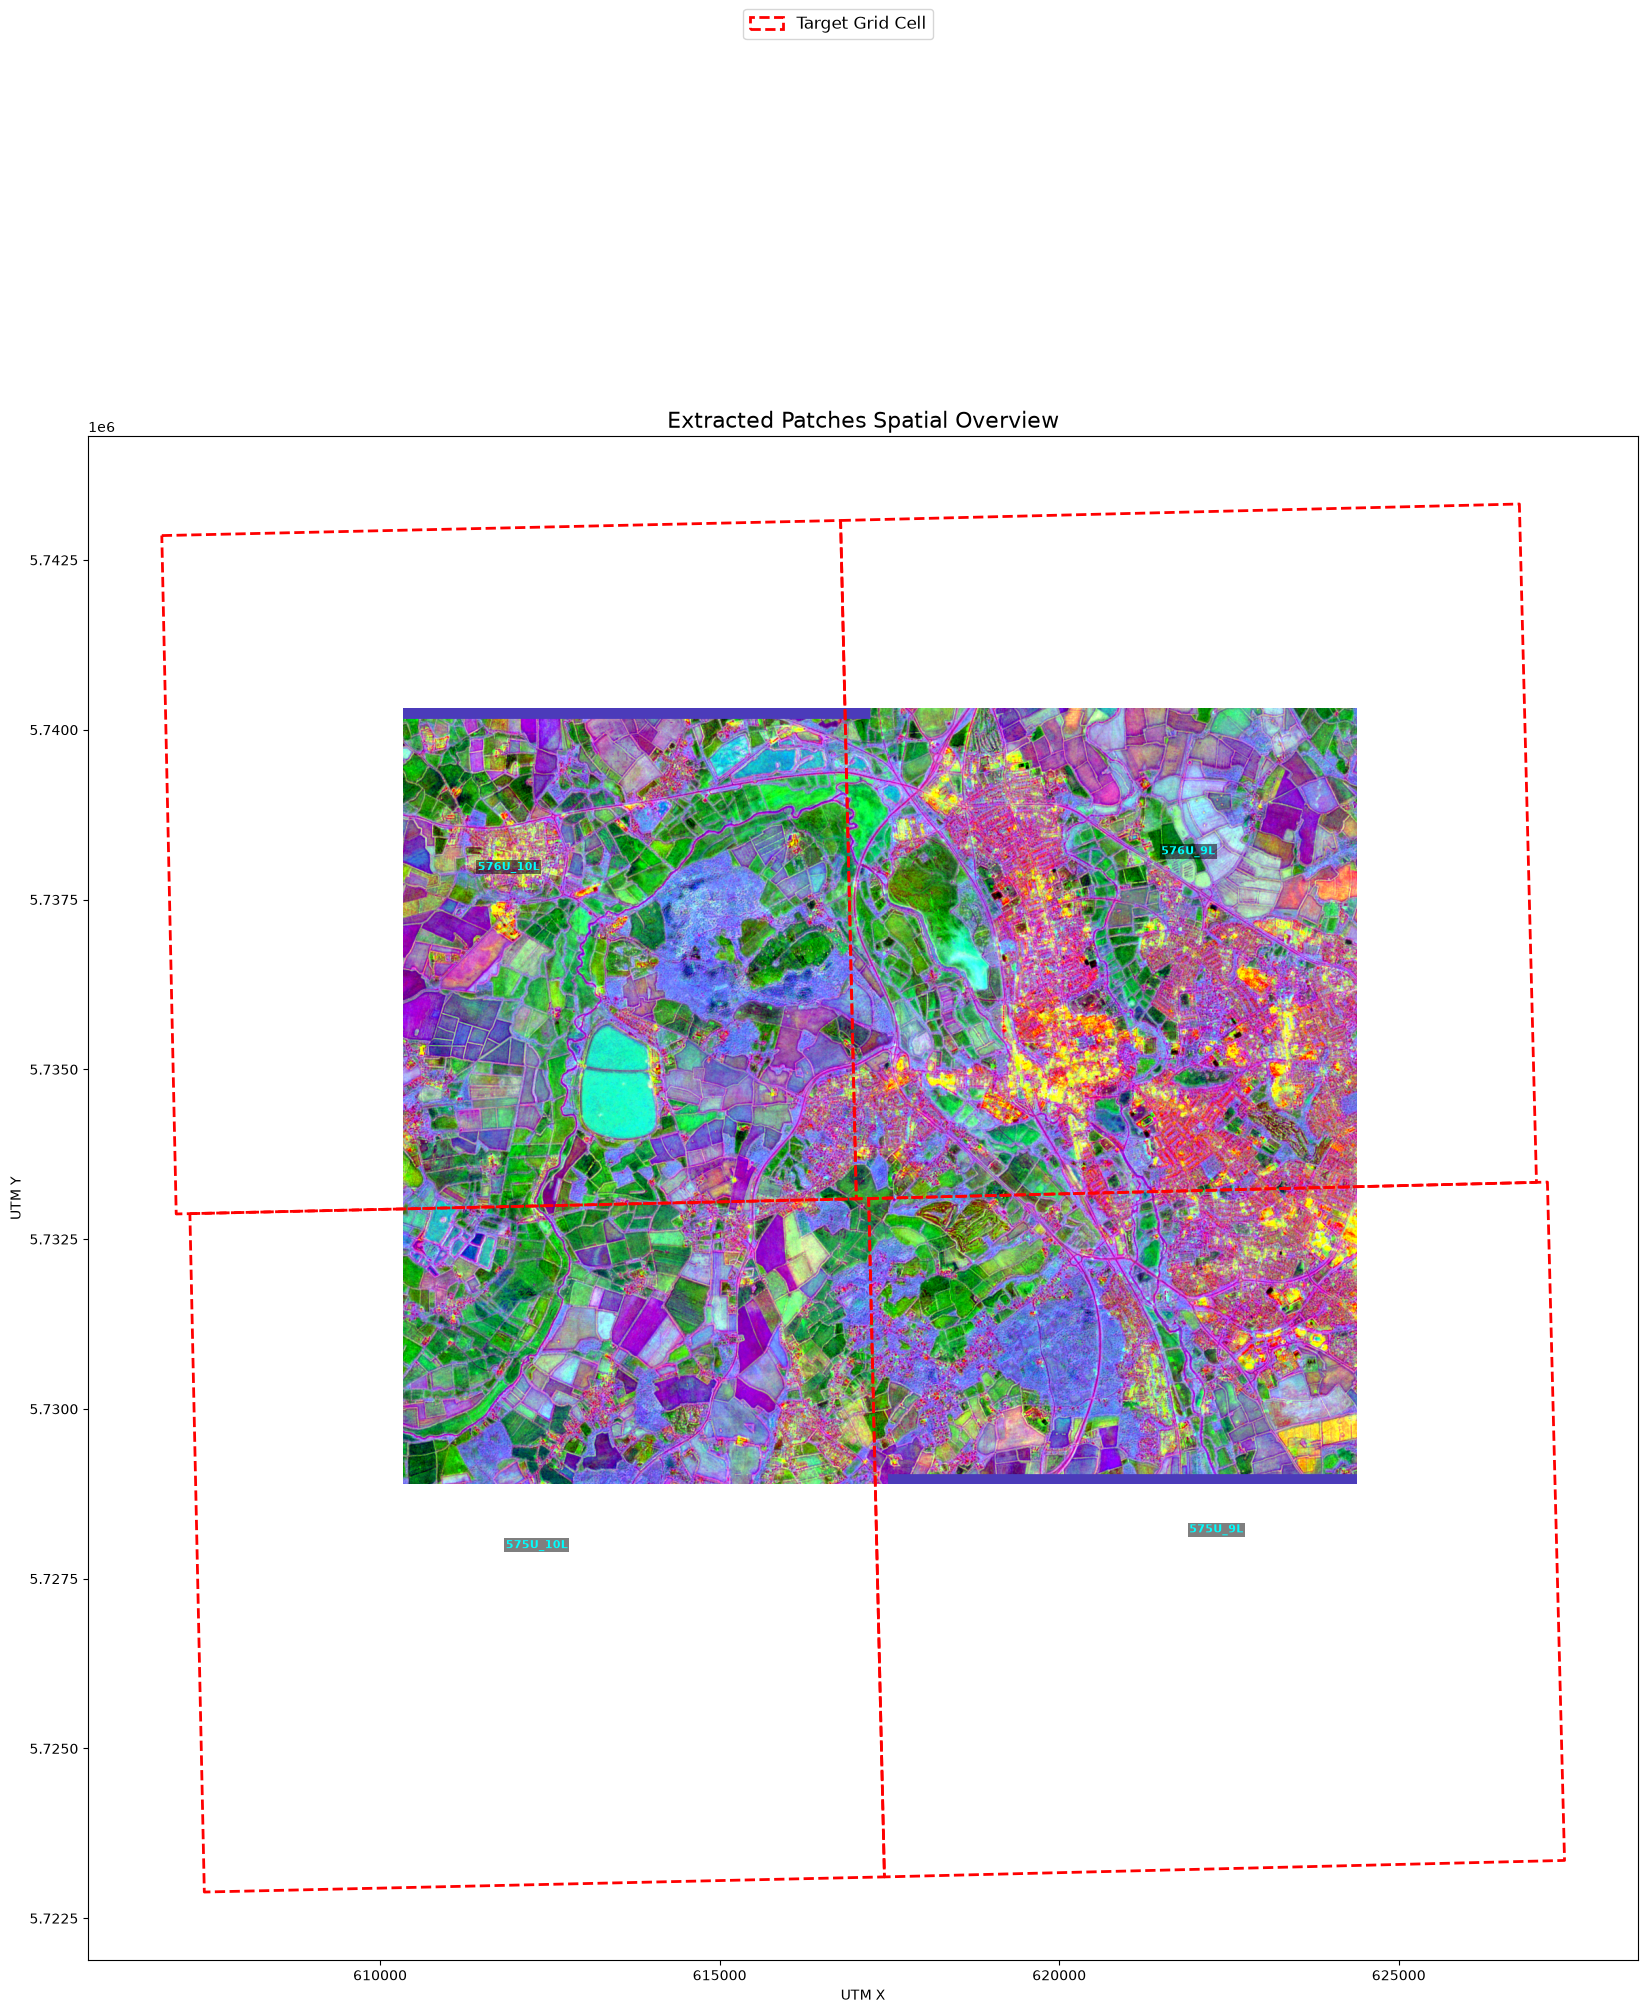

In [13]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, bands=[1, 2, 3], ds_factor=1, stretch="percentile")